In [21]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
# load packages
import os
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from Library.data_preprocessor import DataPreprocessor
from Library.visualizer import TVVisualizer

In [2]:
# load data
data_path = os.path.join(project_root, 'raw_data.csv')
df = pd.read_csv(data_path, low_memory=False)
df['timeslot_datetime_from'] = pd.to_datetime(df['timeslot_datetime_from'])

# --- IMPLEMENTATION ---
FIX_COLS = ['main_ident', 'timeslot_datetime_from', 'channel_id', 'share_15_54', 'share_15_54_3mo_mean']
TARGET = 'share_15_54'

preprocessor = DataPreprocessor(FIX_COLS, TARGET)
processed_df = preprocessor.run(df)



EDA CHANNEL

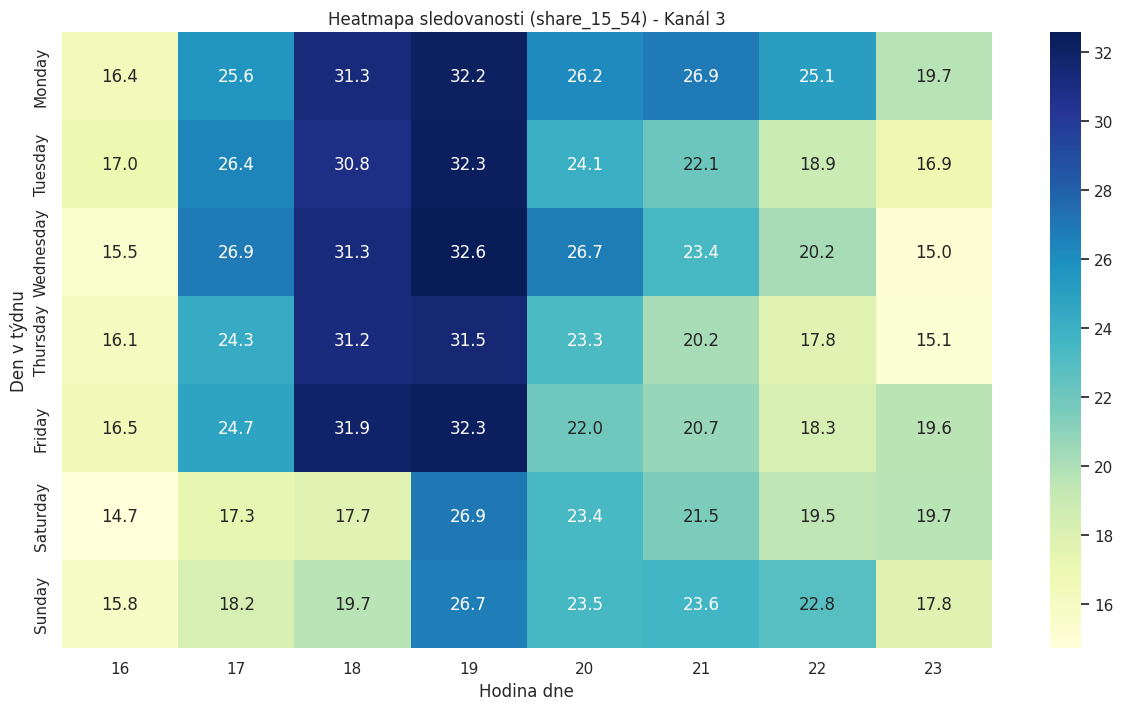

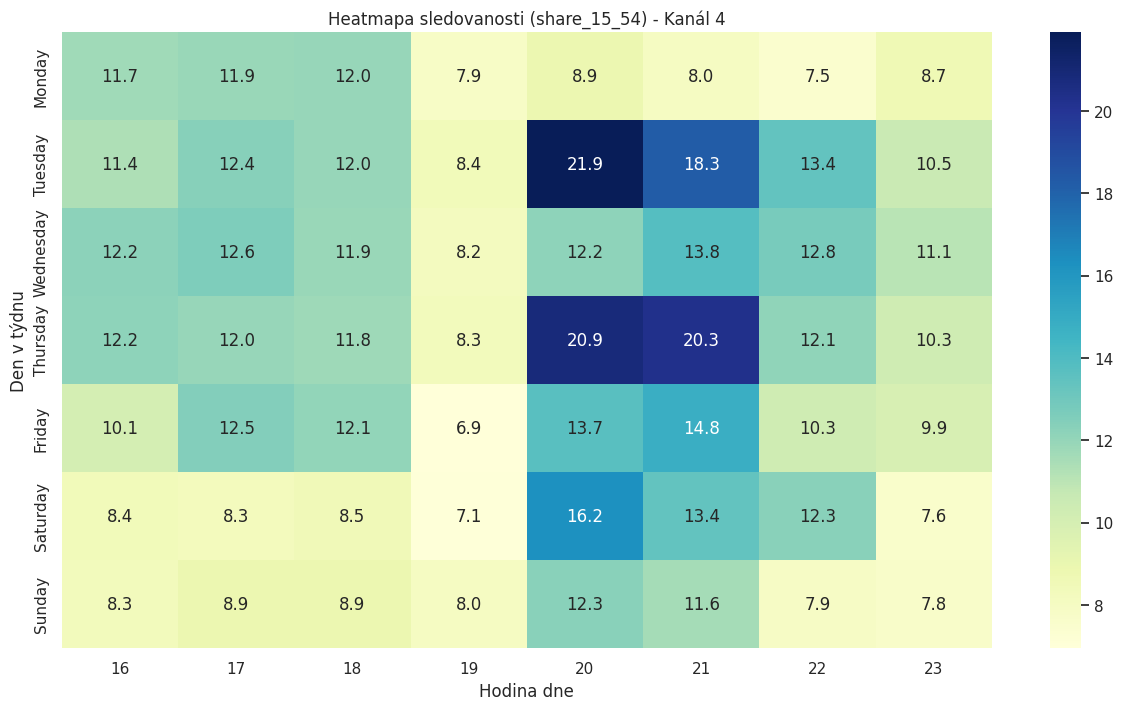

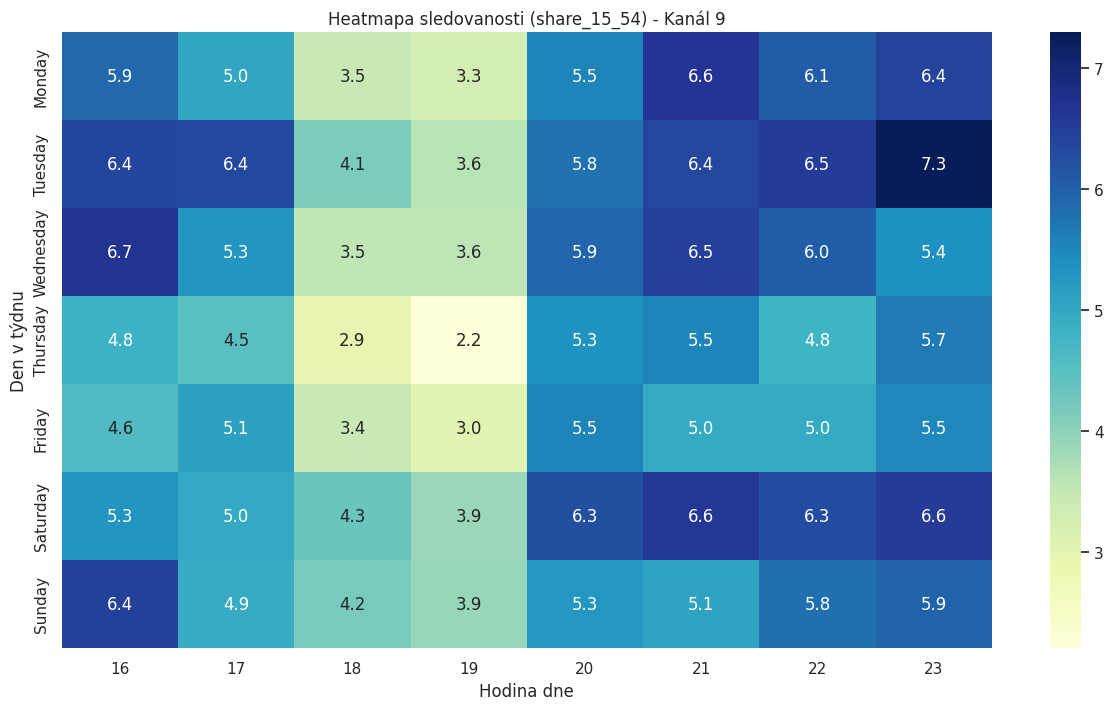

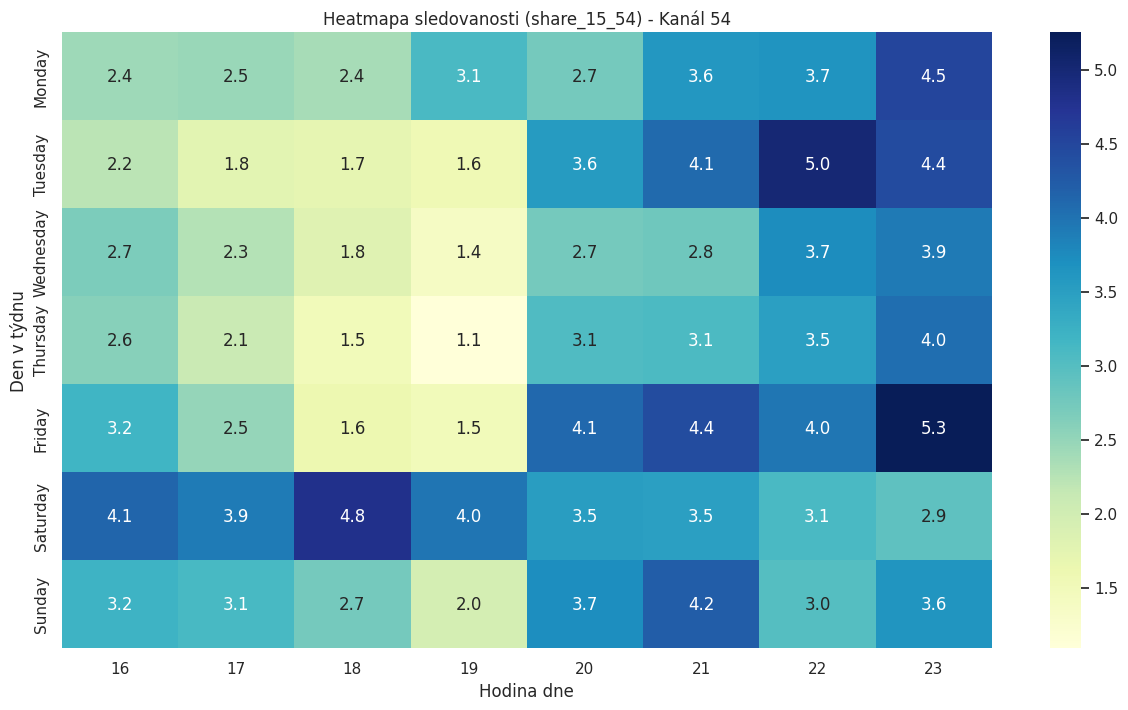

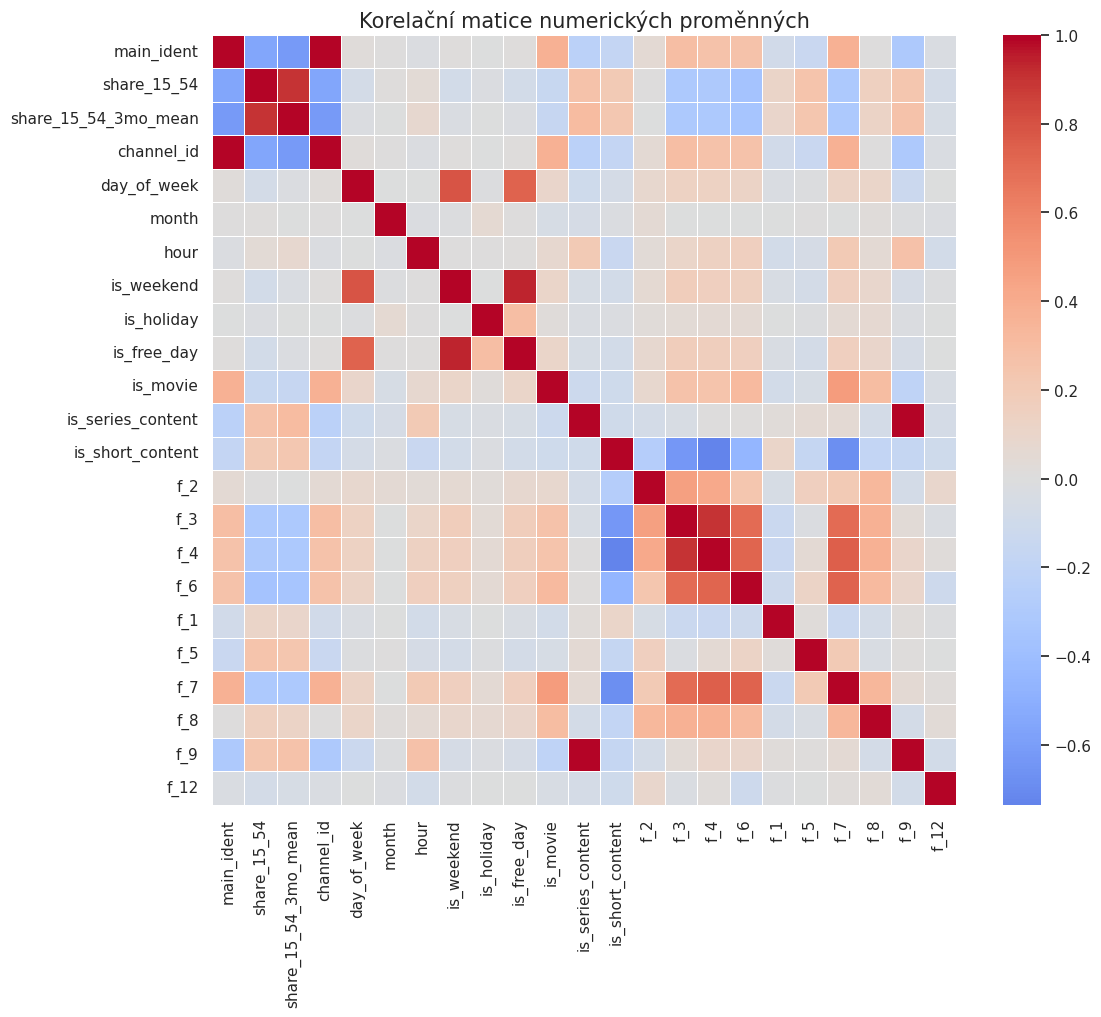

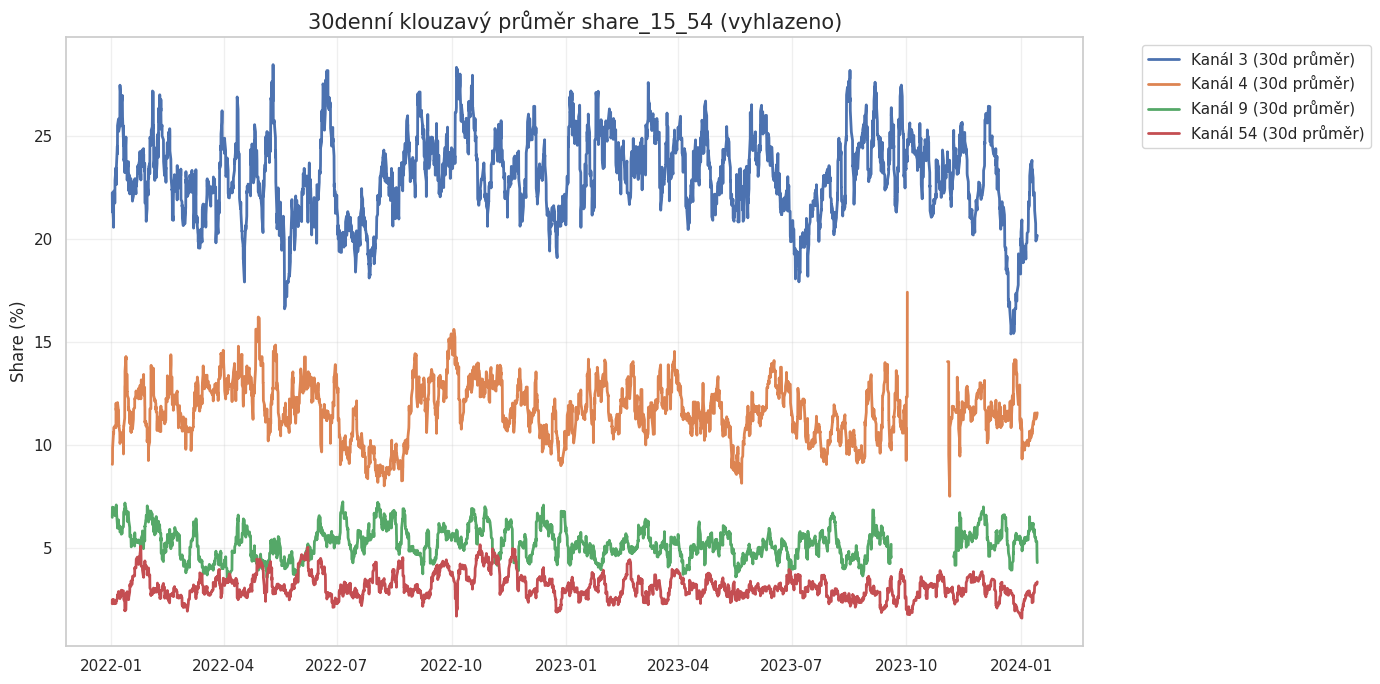

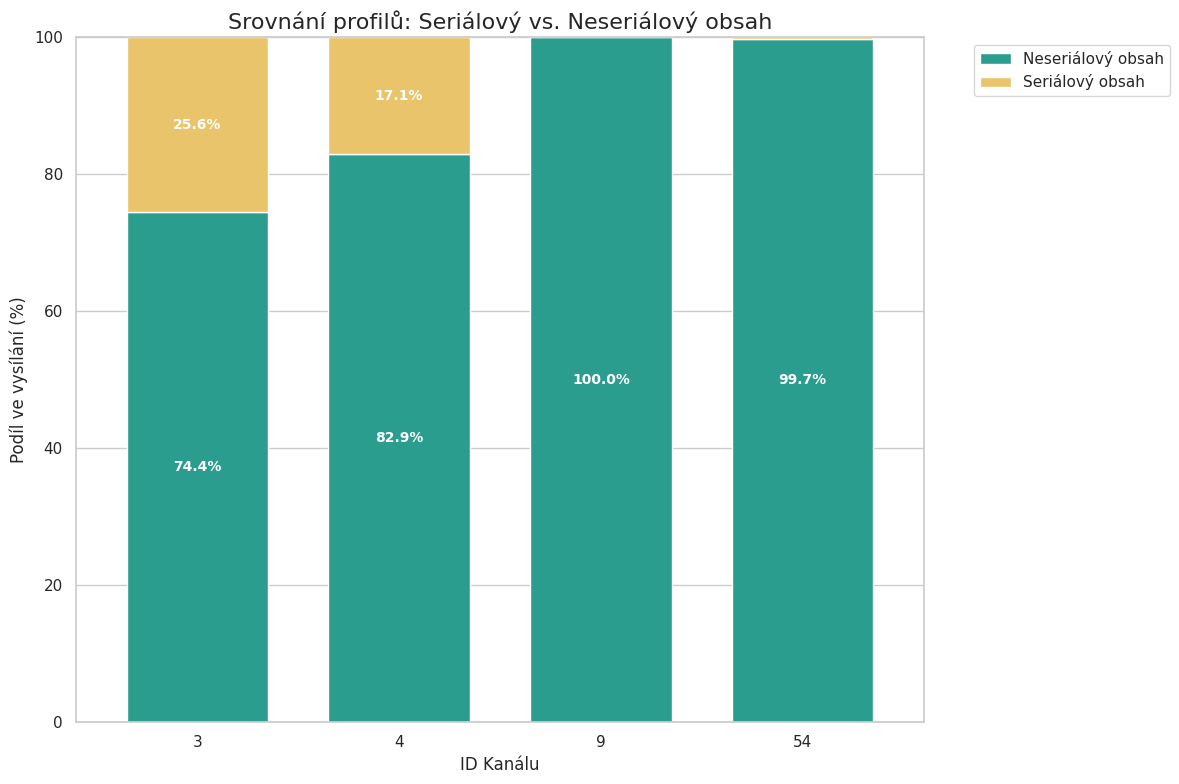

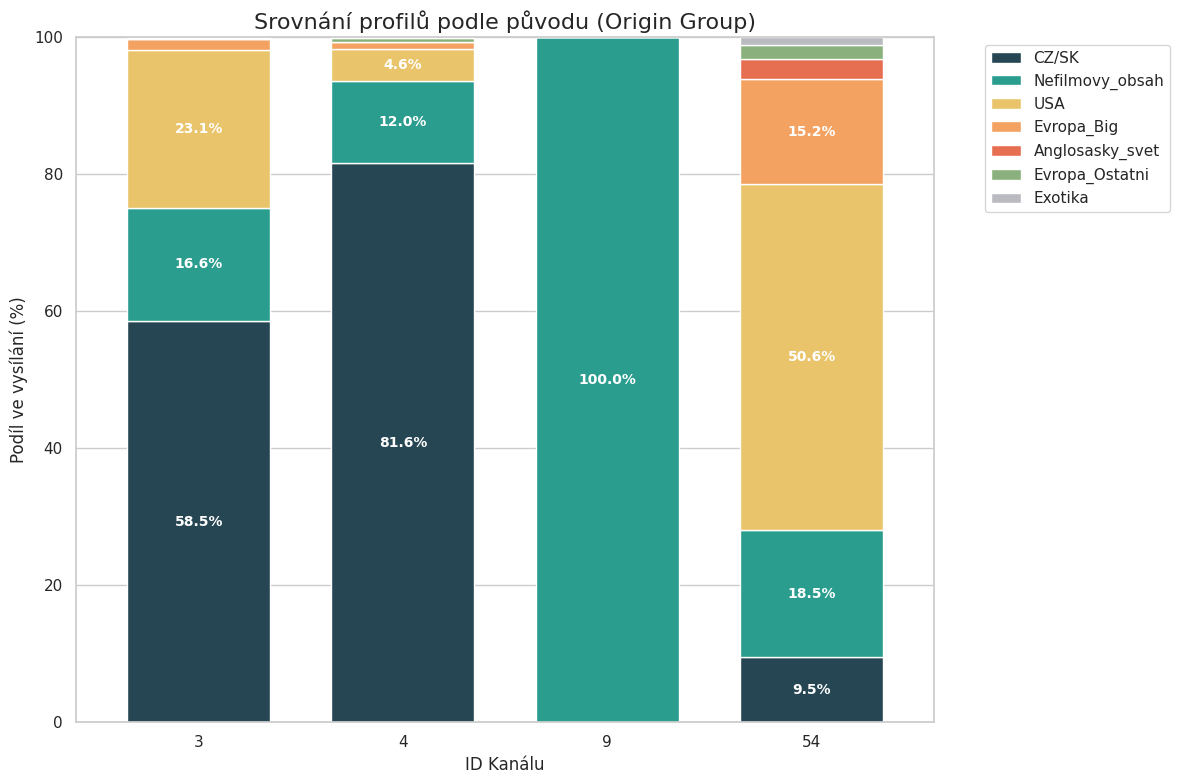

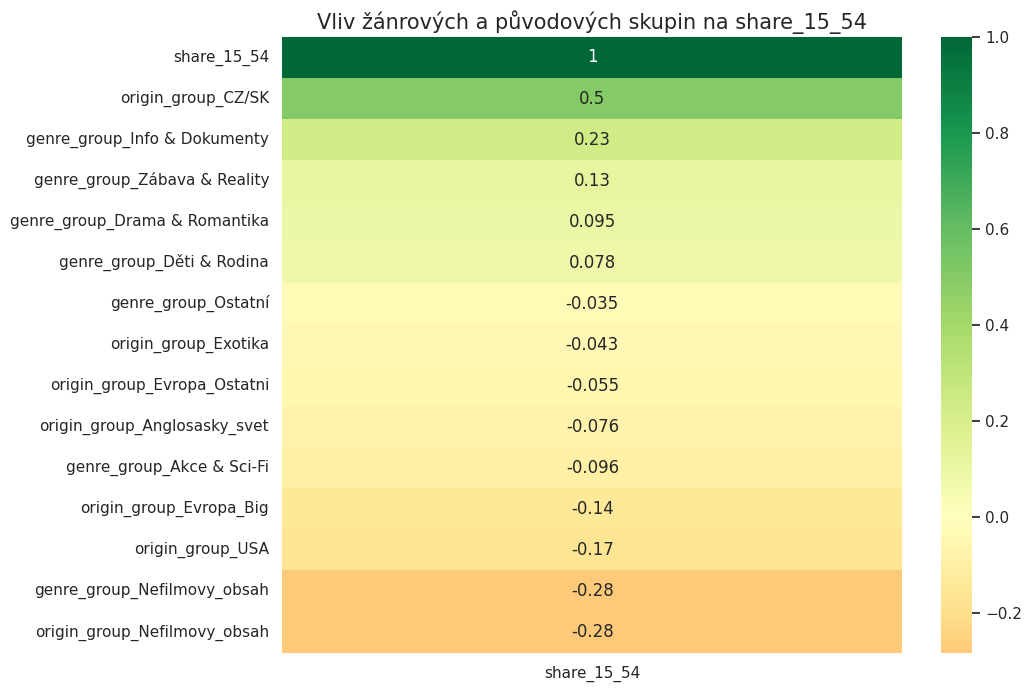

In [5]:
# --- Použití ---
viz = TVVisualizer(processed_df)
viz.plot_channel_heatmap(3)
viz.plot_channel_heatmap(4)
viz.plot_channel_heatmap(9)
viz.plot_channel_heatmap(54)
viz.plot_correlation_matrix()
viz.plot_rolling_share()
viz.plot_content_type_profile()
viz.plot_origin_profile()
viz.plot_category_impact()

# Analýza sledovanosti kanálů skupiny Nova (Target 15-54)

Na základě zpracovaných dat jsem provedl hloubkovou analýzu výkonnosti našich čtyř klíčových kanálů. Níže uvádím hlavní závěry vyplývající z vizualizací:

---

## 1. Tržní postavení a stabilita
* **Hlavní Nova (Kanál 3):** Naprostý leader trhu s průměrným sharem **20–25 %**. Vývoj je dlouhodobě stabilní, což potvrzuje i extrémně silná korelace mezi aktuálním výkonem a 3měsíčním průměrem.
* **Nova Fun (Kanál 4):** Vykazuje největší dynamiku. S průměrem kolem **12 %** je patrné, že úspěch stojí na konkrétních programových blocích (večerní špičky v úterý a čtvrtek).
* **Nova News (Kanál 9) & Nova Cinema (Kanál 54):** Plní roli stabilních doplňkových kanálů (**5 % a 3 % share**). Mají své věrné publikum a vykazují minimální výkyvy.

---

## 2. Co reálně táhne share nahoru?

| Faktor | Vliv na sledovanost | Detail analýzy |
| :--- | :---: | :--- |
| **Lokální produkce (CZ/SK)** | **Vysoký** | Nejsilnější faktor úspěchu (koeficient **0.5**). Kanály stavějící na domácím obsahu mají zásadně vyšší share. |
| **Seriálový model** | **Střední** | Hlavní Nova a Nova Fun těží z pravidelných seriálů (17–25 % vysílání), které budují diváckou věrnost. |
| **Akvizice (USA)** | **Nízký / Záporný** | Mírně negativní korelace (**-0.17**). Samotné americké filmy bez lokálního doprovodu již nejsou hlavním tahounem. |

---

## 3. Časové vzorce a Prime Time
* **Dominance v 19:00–21:00:** Hlavní Nova v tomto slotu pravidelně přesahuje **30 % share**, což je nejsilnější časový úsek dne.
* **Alternativní špičky:** Nova Fun a Nova Cinema zachycují diváky v pozdějších hodinách (**21:00–23:00**). Zejména páteční a sobotní večery na Cinema vykazují zajímavý nárůst.

---

## 4. Žánrové preference
Z heatmapy vlivu kategorií vyplývají tyto trendy:
* **Pozitivní dopad:** Žánry *Info & Dokumenty* (zpravodajství) a *Zábava & Reality*.
* **Negativní dopad:** Čistě "technický" obsah (např. teleshopping) vykazuje nejsilnější negativní korelaci (**-0.28**).

---

---

### Závěr
Strategie multikanálového zásahu funguje efektivně díky jasné profilaci jednotlivých stanic:

1.  **Nova:** Mainstream / Lokální tvorba (vlajková loď)
2.  **Nova Fun:** Seriály / Mladší publikum (dynamický růst)
3.  **Nova Cinema:** Filmový obsah (stabilní filmová knihovna)
4.  **Nova News:** Denní zpravodajství ze světa / Starší diváci (informační servis)

---

### Strategické riziko a budoucí vývoj
Při predikci budoucího vývoje musíme brát v úvahu měnící se divácké návyky:

* **Odklon od lineární TV:** Mladší generace (Gen Z a mileniálové) se přesouvá od klasického televizního vysílání ke **streamovacím platformám** (VOD).
* **Ztráta Prime Timu:** Kvůli "on-demand" sledování (kdykoliv a kdekoliv) dochází k postupné erozi významu hlavního vysílacího času. Tradiční "Prime Time" u lineární TV bude čelit poklesu kumulovaného zásahu.
* **Doporučení:** Klíčem k udržení tržního podílu bude posilování synergie mezi lineárním vysíláním a digitálními platformami (např. Voyo), kde lokální obsah funguje jako hlavní akviziční magnet i v nelineárním prostředí.

**Klíčové shrnutí:** Prioritizace lokální (CZ/SK) tvorby zůstává zásadním prvkem pro udržení tržního podílu, neboť vykazuje nejsilnější diváckou vazbu napříč všemi platformami.